# Seasonal Agriculture Performance Analysis
**Objective:** Analyze the supplied agricultural dataset to uncover seasonal differences, performance patterns, relationships, variations, and evidence-based insights.



In [1]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 1. Dataset Loading


In [3]:
raw = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

print(f"Dataset shape: {raw.shape[0]:,} rows × {raw.shape[1]:,} columns")
display(raw.head())


Dataset shape: 4,000 rows × 28 columns


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 2. Data Audit


In [4]:
audit = pd.DataFrame({
    "column": raw.columns,
    "dtype": raw.dtypes.astype(str).values,
    "missing": raw.isna().sum().values,
    "missing_%": (raw.isna().mean().values * 100).round(2),
    "unique": raw.nunique(dropna=True).values
})
display(audit.sort_values(["missing_%", "unique"], ascending=[False, True]))

print("Duplicate rows:", raw.duplicated().sum())
print("Numeric columns:", raw.select_dtypes(include=np.number).columns.tolist())
print("Categorical columns:", raw.select_dtypes(exclude=np.number).columns.tolist())


,column,dtype,missing,missing_%,unique
6,Rainfall_mm,float64,48,1.2,3256
11,Soil_Moisture_pct,float64,40,1.0,343
19,Yield_Tonnes_Ha,float64,32,0.8,738
4,Season,object,0,0.0,3
15,Irrigation_Method,object,0,0.0,4
1,State,object,0,0.0,8
3,Crop,object,0,0.0,8
2,District,object,0,0.0,10
18,Seed_Quality_Score,float64,0,0.0,36
9,Sunlight_Hours_Day,float64,0,0.0,71


Duplicate rows: 0
Numeric columns: ['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']
Categorical columns: ['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


In [5]:
display(raw.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF13984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,4000.0,NaN,NaN,NaN,7.888265,4.223764,0.5,4.26,7.895,11.65,15.0
Rainfall_mm,3952.0,NaN,NaN,NaN,601.152657,288.925025,80.0,370.2,582.0,834.95,1395.2
Avg_Temperature_C,4000.0,NaN,NaN,NaN,26.8189,3.81818,16.2,23.9,26.9,29.6,39.7
Humidity_pct,4000.0,NaN,NaN,NaN,63.2105,11.960834,25.0,54.775,63.0,71.9,95.0
Sunlight_Hours_Day,4000.0,NaN,NaN,NaN,7.32305,1.121186,3.5,6.6,7.3,8.1,11.0


## 3. Data Cleaning & Preparation




In [6]:
data = raw.copy()

duplicates_removed = int(data.duplicated().sum())
data = data.drop_duplicates().reset_index(drop=True)

In [10]:
print("Duplicates removed:",duplicates_removed)

Duplicates removed: 0


In [7]:
data.columns = (
    data.columns.astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

In [11]:
for c in data.select_dtypes(include="object").columns:
    data[c] = data[c].astype(str).str.strip()

for c in data.columns:
    if data[c].dtype == "object":
        converted = pd.to_numeric(data[c].str.replace(",", "", regex=False), errors="coerce")
        valid = data[c].notna().sum()
        if valid > 0 and converted.notna().sum() / valid >= 0.90:
            data[c] = converted

print(print("Clean dataset:", data.shape[0], "rows ×", data.shape[1], "columns"))
display(data.head())

Clean dataset: 4000 rows × 28 columns
None


,farm_id,state,district,crop,season,farm_area_hectares,rainfall_mm,avg_temperature_c,humidity_pct,sunlight_hours_day,...,seed_quality_score,yield_tonnes_ha,production_tonnes,market_price_inr_tonne,total_cost_inr,revenue_inr,profit_inr,water_used_m3,water_efficiency_t_per_1000m3,disease_pest_risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [12]:
quality = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "missing": data.isna().sum(),
    "missing_%": (data.isna().mean()*100).round(2),
    "unique": data.nunique(dropna=True)
})
display(quality)


,dtype,missing,missing_%,unique
farm_id,object,0,0.0,4000
state,object,0,0.0,8
district,object,0,0.0,10
crop,object,0,0.0,8
season,object,0,0.0,3
farm_area_hectares,float64,0,0.0,1370
rainfall_mm,float64,48,1.2,3256
avg_temperature_c,float64,0,0.0,204
humidity_pct,float64,0,0.0,573
sunlight_hours_day,float64,0,0.0,71


## 4. Analytical Field Map


In [13]:
season_col = 'season'
region_col = 'district'
performance_col = 'yield_tonnes_ha'
economic_col = 'revenue_inr'
rainfall_col = 'rainfall_mm'
temperature_col = 'avg_temperature_c'
water_col = 'irrigation_method'
fertilizer_col = 'fertilizer_kg_ha'

field_map = pd.DataFrame({
    "analytical_role": [
        "Season dimension", "Region/area dimension", "Primary performance KPI",
        "Economic KPI", "Rainfall", "Temperature", "Water/Irrigation", "Fertilizer"
    ],
    "detected_column": [
        season_col, region_col, performance_col, economic_col,
        rainfall_col, temperature_col, water_col, fertilizer_col
    ]
})
display(field_map)


,analytical_role,detected_column
0,Season dimension,season
1,Region/area dimension,district
2,Primary performance KPI,yield_tonnes_ha
3,Economic KPI,revenue_inr
4,Rainfall,rainfall_mm
5,Temperature,avg_temperature_c
6,Water/Irrigation,irrigation_method
7,Fertilizer,fertilizer_kg_ha


## 5. EDA — What Does the Dataset Look Like?

### Question 1 — What are the major characteristics of the agricultural records?


In [14]:
numeric_cols = data.select_dtypes(include=np.number).columns.tolist()
categorical_cols = data.select_dtypes(include="object").columns.tolist()

display(data[numeric_cols].agg(["count","mean","median","std","min","max"]).T)

if categorical_cols:
    cat_profile = pd.DataFrame({
        "column": categorical_cols,
        "unique_values": [data[c].nunique(dropna=True) for c in categorical_cols],
        "most_common": [
            data[c].mode(dropna=True).iloc[0] if not data[c].mode(dropna=True).empty else np.nan
            for c in categorical_cols
        ]
    })
    display(cat_profile.sort_values("unique_values"))


,count,mean,median,std,min,max
farm_area_hectares,4000.0,7.888265,7.8950,4.223764,0.500,15.00
rainfall_mm,3952.0,601.152657,582.0000,288.925025,80.000,1395.20
avg_temperature_c,4000.0,26.818900,26.9000,3.818180,16.200,39.70
humidity_pct,4000.0,63.210500,63.0000,11.960834,25.000,95.00
sunlight_hours_day,4000.0,7.323050,7.3000,1.121186,3.500,11.00
soil_ph,4000.0,6.701010,6.6900,0.641461,5.200,8.40
soil_moisture_pct,3960.0,26.508232,26.4000,6.712484,8.000,47.00
nitrogen_kg_ha,4000.0,120.250825,120.1000,31.216452,40.000,220.00
phosphorus_kg_ha,4000.0,57.781850,57.5000,17.015074,15.000,120.00
potassium_kg_ha,4000.0,104.760050,105.1000,27.742681,30.000,200.00


,column,unique_values,most_common
4,season,3,Kharif
5,irrigation_method,4,Flood
1,state,8,Andhra Pradesh
3,crop,8,Rice
2,district,10,Ludhiana
0,farm_id,4000,SF10001


## 6. Seasonal Performance — Core Analysis

### Question 2 — How does agricultural performance vary across seasons?

In [15]:
if season_col and performance_col:
    seasonal = (
        data.groupby(season_col)[performance_col]
        .agg(records="count", mean="mean", median="median", std="std", minimum="min", maximum="max")
        .sort_values("mean", ascending=False)
    )
    display(seasonal.round(2))
else:
    print("Season/performance field unavailable.")


,records,mean,median,std,minimum,maximum
season,,,,,,
Kharif,1772,5.64,1.95,14.42,0.3,101.44
Rabi,1607,5.08,1.66,12.83,0.3,93.13
Zaid,589,4.67,1.45,11.32,0.3,64.76


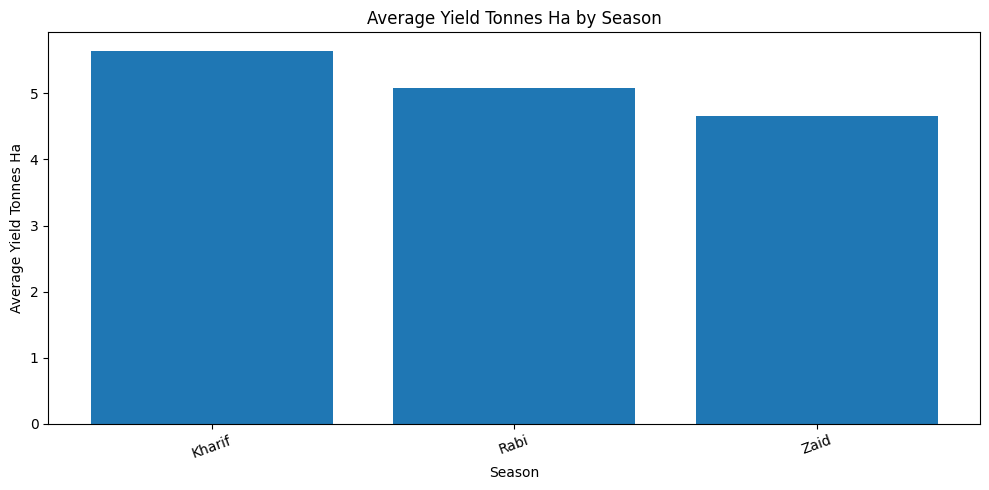

In [16]:
if season_col and performance_col:
    means = data.groupby(season_col)[performance_col].mean().sort_values(ascending=False)
    plt.figure(figsize=(10,5))
    plt.bar(means.index.astype(str), means.values)
    plt.title(f"Average {performance_col.replace('_',' ').title()} by Season")
    plt.xlabel("Season")
    plt.ylabel(f"Average {performance_col.replace('_',' ').title()}")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


## 7. Seasonal Consistency

### Question 3 — Which seasons are relatively stable versus volatile?



,mean,std,count,cv_%
season,,,,
Kharif,5.64,14.42,1772,255.48
Rabi,5.08,12.83,1607,252.44
Zaid,4.67,11.32,589,242.56


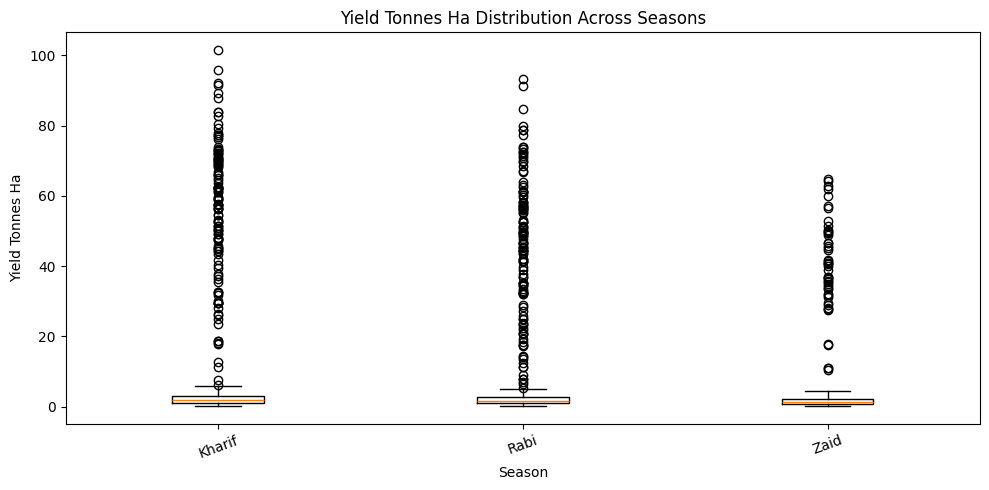

In [17]:
if season_col and performance_col:
    consistency = data.groupby(season_col)[performance_col].agg(["mean","std","count"])
    consistency["cv_%"] = np.where(
        consistency["mean"].abs() > 1e-12,
        consistency["std"].abs()/consistency["mean"].abs()*100,
        np.nan
    )
    display(consistency.sort_values("mean", ascending=False).round(2))

    seasons = data[season_col].dropna().unique()
    groups = [data.loc[data[season_col] == s, performance_col].dropna() for s in seasons]
    plt.figure(figsize=(10,5))
    plt.boxplot(groups, tick_labels=[str(s) for s in seasons])
    plt.title(f"{performance_col.replace('_',' ').title()} Distribution Across Seasons")
    plt.xlabel("Season")
    plt.ylabel(performance_col.replace("_"," ").title())
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


## 8. Seasonal Driver Analysis

### Question 4 — Which measurable variables are associated with agricultural performance?


,correlation_with_yield_tonnes_ha
yield_tonnes_ha,1.000000
water_efficiency_t_per_1000m3,0.915438
production_tonnes,0.885171
profit_inr,0.489822
revenue_inr,0.433648
water_used_m3,0.388653
nitrogen_kg_ha,0.053867
phosphorus_kg_ha,0.047821
rainfall_mm,0.030853
total_cost_inr,0.030814


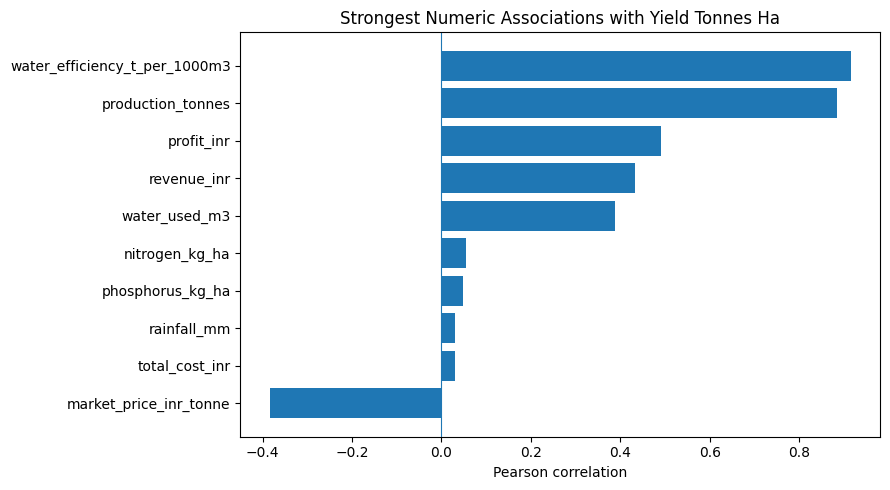

In [18]:
if performance_col in numeric_cols:
    corr = data[numeric_cols].corr(numeric_only=True)[performance_col].dropna().sort_values(ascending=False)
    display(corr.to_frame(f"correlation_with_{performance_col}"))

    ranked = corr.drop(labels=[performance_col], errors="ignore").abs().sort_values(ascending=False)
    if len(ranked):
        top = ranked.index[:10]
        vals = corr.loc[top].sort_values()
        plt.figure(figsize=(9,5))
        plt.barh(vals.index.astype(str), vals.values)
        plt.axvline(0, linewidth=0.8)
        plt.title(f"Strongest Numeric Associations with {performance_col.replace('_',' ').title()}")
        plt.xlabel("Pearson correlation")
        plt.tight_layout()
        plt.show()


## 9. Seasonal Environment & Resource Profile

### Question 5 — What changes across seasons in the measurable environmental/resource variables?


,rainfall_mm,avg_temperature_c,fertilizer_kg_ha
season,,,
Kharif,852.08,28.45,187.08
Rabi,436.00,23.49,185.41
Zaid,299.42,31.04,184.64


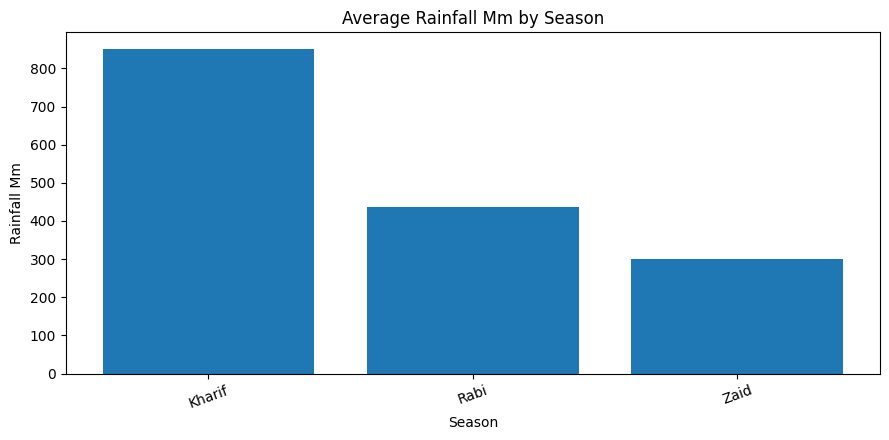

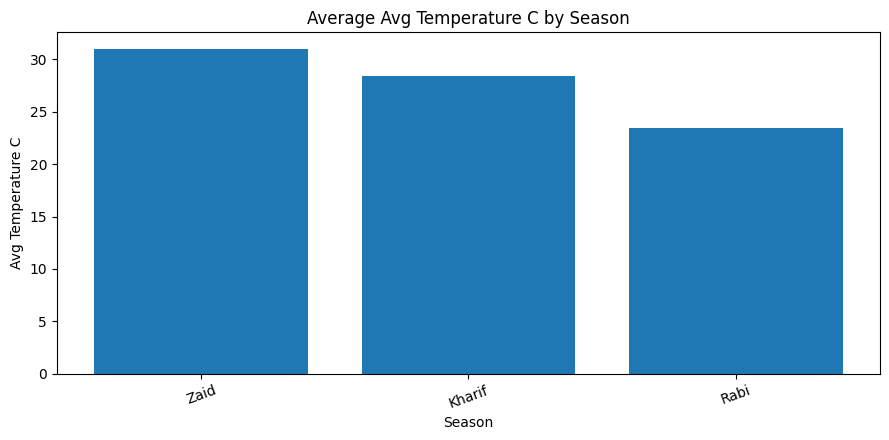

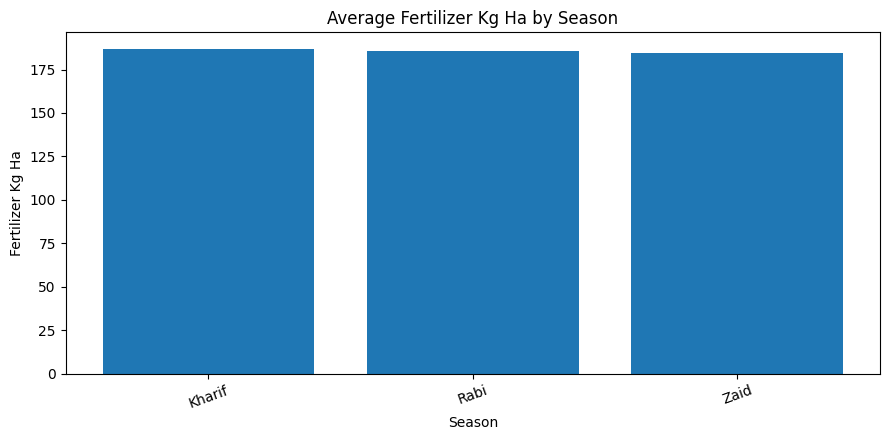

In [20]:
factor_cols = [
    c for c in [rainfall_col, temperature_col, fertilizer_col]
    if c and c in data.columns
]

if season_col and factor_cols:
    display(data.groupby(season_col)[factor_cols].mean().round(2))

    for factor in factor_cols:
        avg = data.groupby(season_col)[factor].mean().sort_values(ascending=False)

        plt.figure(figsize=(9, 4.5))
        plt.bar(avg.index.astype(str), avg.values)
        plt.title("Average " + factor.replace("_", " ").title() + " by Season")
        plt.xlabel("Season")
        plt.ylabel(factor.replace("_", " ").title())
        plt.xticks(rotation=20)
        plt.tight_layout()
        plt.show()
else:
    print("No matching environmental/resource fields were detected.")

irrigation_method,Drip,Flood,Rainfed,Sprinkler
season,,,,
Kharif,22.77,33.16,26.03,18.04
Rabi,22.74,32.33,26.92,18.01
Zaid,23.57,32.66,23.57,20.20


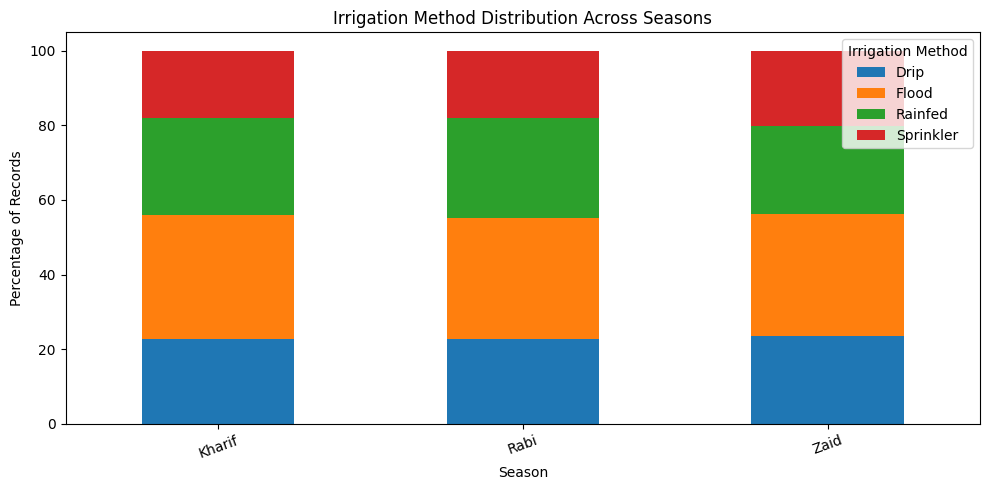

In [21]:
if season_col and water_col:
    irrigation_by_season = pd.crosstab(
        data[season_col],
        data[water_col],
        normalize="index"
    ) * 100

    display(irrigation_by_season.round(2))

    irrigation_by_season.plot(
        kind="bar",
        figsize=(10, 5),
        stacked=True
    )

    plt.title("Irrigation Method Distribution Across Seasons")
    plt.xlabel("Season")
    plt.ylabel("Percentage of Records")
    plt.xticks(rotation=20)
    plt.legend(title="Irrigation Method")
    plt.tight_layout()
    plt.show()

## 10. Cross-Group Validation

### Question 6 — Are seasonal patterns consistent across regions/areas?



season,Kharif,Rabi,Zaid
district,,,
Erode,4.33,4.48,3.31
Guntur,6.02,4.58,6.30
Indore,6.12,3.54,4.54
Krishna,5.51,4.76,2.91
Ludhiana,6.41,5.62,5.08
Nalgonda,6.58,4.47,7.51
Nashik,5.55,4.72,3.39
Raichur,4.12,6.74,3.29
Rajkot,6.69,5.96,4.33


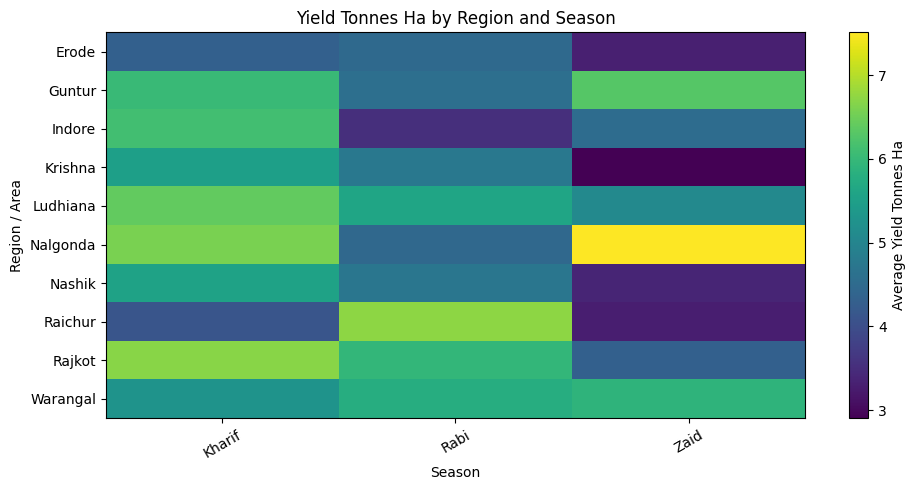

In [22]:
if season_col and region_col and performance_col:
    pivot = pd.pivot_table(
        data, index=region_col, columns=season_col,
        values=performance_col, aggfunc="mean"
    )
    display(pivot.round(2))

    if not pivot.empty:
        plt.figure(figsize=(10, max(5, len(pivot)*0.35)))
        plt.imshow(pivot, aspect="auto")
        plt.colorbar(label=f"Average {performance_col.replace('_',' ').title()}")
        plt.xticks(range(len(pivot.columns)), [str(x) for x in pivot.columns], rotation=30)
        plt.yticks(range(len(pivot.index)), [str(x) for x in pivot.index])
        plt.title(f"{performance_col.replace('_',' ').title()} by Region and Season")
        plt.xlabel("Season")
        plt.ylabel("Region / Area")
        plt.tight_layout()
        plt.show()
else:
    print("Region/season/performance fields unavailable for cross-group analysis.")


## 11. Outlier & Unusual Pattern Analysis

### Question 7 — Where are the unusually high or low observations?



In [23]:
if performance_col:
    x = data[performance_col].dropna()
    q1, q3 = x.quantile([0.25,0.75])
    iqr = q3-q1
    lower, upper = q1-1.5*iqr, q3+1.5*iqr

    outliers = data[(data[performance_col] < lower) | (data[performance_col] > upper)]
    print(f"IQR thresholds: lower={lower:,.2f}, upper={upper:,.2f}")
    print(f"Potential outliers: {len(outliers):,}")
    display(outliers.head(15))


IQR thresholds: lower=-1.63, upper=5.52
Potential outliers: 302


,farm_id,state,district,crop,season,farm_area_hectares,rainfall_mm,avg_temperature_c,humidity_pct,sunlight_hours_day,...,seed_quality_score,yield_tonnes_ha,production_tonnes,market_price_inr_tonne,total_cost_inr,revenue_inr,profit_inr,water_used_m3,water_efficiency_t_per_1000m3,disease_pest_risk_pct
47,SF10048,Punjab,Ludhiana,Sugarcane,Zaid,7.68,90.0,31.9,52.7,9.8,...,0.76,36.69,281.78,3682,480826,1037514,556688,13263,21.246,30.0
75,SF10076,Maharashtra,Guntur,Sugarcane,Kharif,10.64,869.0,33.2,82.3,5.6,...,0.79,62.58,665.85,3651,755288,2431018,1675730,23608,28.204,58.8
79,SF10080,Karnataka,Nashik,Sugarcane,Zaid,9.29,353.9,30.6,46.8,9.1,...,0.90,33.55,311.68,3955,541528,1232694,691166,8213,37.950,31.2
82,SF10083,Andhra Pradesh,Raichur,Sugarcane,Rabi,2.46,629.3,23.5,47.5,8.9,...,0.83,49.52,121.82,3654,165909,445130,279221,2611,46.656,35.2
92,SF10093,Gujarat,Guntur,Sugarcane,Kharif,12.74,973.7,29.9,57.5,7.4,...,0.72,70.23,894.73,3671,856862,3284554,2427692,18596,48.114,51.9
113,SF10114,Tamil Nadu,Rajkot,Sugarcane,Rabi,14.35,740.8,24.8,72.5,7.9,...,0.92,58.06,833.16,3807,847509,3171840,2324331,27123,30.718,64.2
132,SF10133,Telangana,Warangal,Sugarcane,Kharif,3.83,1158.2,27.2,68.4,7.0,...,0.82,29.47,112.87,3123,263380,352493,89113,6337,17.811,53.9
154,SF10155,Telangana,Ludhiana,Sugarcane,Kharif,9.12,932.6,29.3,65.5,8.7,...,0.82,47.88,436.67,3550,751898,1550178,798280,21550,20.263,54.4
155,SF10156,Madhya Pradesh,Guntur,Sugarcane,Kharif,4.50,867.9,27.3,66.6,7.2,...,0.82,62.09,279.41,3089,290078,863097,573019,8473,32.977,48.7
164,SF10165,Telangana,Guntur,Sugarcane,Rabi,4.00,391.2,25.6,59.8,8.7,...,0.67,36.91,147.64,3771,259517,556750,297233,3618,40.807,24.0


## 12. Relative Seasonal Performance Index

A seasonal index above 100 means that season's average is above the overall average; below 100 means below it.


,season_average,performance_index
season,,
Kharif,5.64,107.08
Rabi,5.08,96.39
Zaid,4.67,88.53


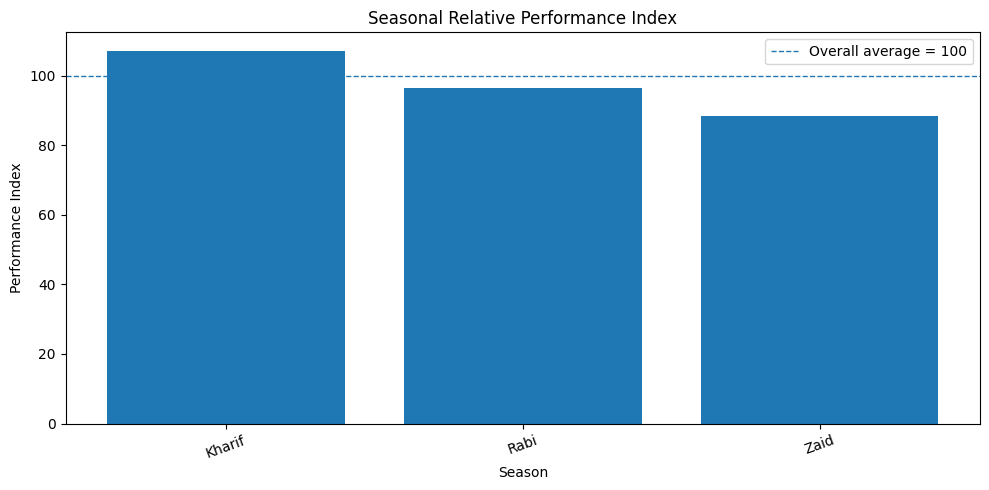

In [24]:
if season_col and performance_col:
    overall = data[performance_col].mean()
    index = data.groupby(season_col)[performance_col].mean().to_frame("season_average")
    index["performance_index"] = index["season_average"]/overall*100
    index = index.sort_values("performance_index", ascending=False)

    display(index.round(2))

    plt.figure(figsize=(10,5))
    plt.bar(index.index.astype(str), index["performance_index"])
    plt.axhline(100, linewidth=1, linestyle="--", label="Overall average = 100")
    plt.title("Seasonal Relative Performance Index")
    plt.xlabel("Season")
    plt.ylabel("Performance Index")
    plt.legend()
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


## 13. Evidence-Based Findings



In [26]:
findings = []


In [29]:
# 1. Seasonal performance finding
if season_col and performance_col:

    seasonal_performance = (
        data.groupby(season_col)[performance_col]
        .mean()
        .dropna()
        .sort_values(ascending=False)
    )

    if len(seasonal_performance) >= 2:

        best_season = seasonal_performance.index[0]
        worst_season = seasonal_performance.index[-1]

        performance_gap = (
            seasonal_performance.iloc[0]
            - seasonal_performance.iloc[-1]
        )

        findings.append(
            "Seasonal Performance: "
            + str(best_season)
            + " records the highest average "
            + performance_col.replace("_", " ")
            + ", while "
            + str(worst_season)
            + " records the lowest. "
            + "The mean difference is "
            + "{:,.2f}".format(performance_gap)
            + "."
        )


    # 2. Seasonal consistency finding
    consistency = (
        data.groupby(season_col)[performance_col]
        .agg(["mean", "std"])
    )

    consistency["cv"] = np.where(
        consistency["mean"].abs() > 1e-12,
        consistency["std"].abs() / consistency["mean"].abs(),
        np.nan
    )

    consistency = consistency.dropna(subset=["cv"])

    if len(consistency) > 0:

        most_consistent = consistency["cv"].idxmin()
        most_variable = consistency["cv"].idxmax()

        findings.append(
            "Consistency: "
            + str(most_consistent)
            + " shows the lowest relative variability, while "
            + str(most_variable)
            + " shows the highest coefficient of variation among the seasons."
        )

In [30]:
# 3. Relationship finding
if performance_col in numeric_cols:

    correlation_values = (
        data[numeric_cols]
        .corr(numeric_only=True)[performance_col]
        .drop(labels=[performance_col], errors="ignore")
        .dropna()
    )

    if len(correlation_values) > 0:

        strongest_variable = (
            correlation_values.abs().idxmax()
        )

        strongest_correlation = (
            correlation_values[strongest_variable]
        )

        findings.append(
            "Relationship Signal: "
            + strongest_variable.replace("_", " ")
            + " has the strongest absolute Pearson correlation with "
            + performance_col.replace("_", " ")
            + ". The correlation is "
            + "{:.2f}".format(strongest_correlation)
            + ". This indicates association, not causation."
        )

In [31]:
# 4. Display the findings
if findings:

    print("KEY DATA-DRIVEN FINDINGS")
    print("=" * 70)

    for number, finding in enumerate(findings, start=1):

        print(str(number) + ". " + finding)
        print()

else:

    print("Insufficient detected fields for automated findings.")

KEY DATA-DRIVEN FINDINGS
1. Seasonal Performance: Kharif records the highest average yield tonnes ha, while Zaid records the lowest. The mean difference is 0.98.

2. Seasonal Performance: Kharif records the highest average yield tonnes ha, while Zaid records the lowest. The mean difference is 0.98.

3. Consistency: Zaid shows the lowest relative variability, while Kharif shows the highest coefficient of variation among the seasons.

4. Relationship Signal: water efficiency t per 1000m3 has the strongest absolute Pearson correlation with yield tonnes ha. The correlation is 0.92. This indicates association, not causation.



## 14. Recommendations

- **Focus on better-performing seasons:** Use the seasonal results to plan resources and farming activities more effectively.

- **Look closely at Zaid:** Investigate the reasons behind its lower profitability and water efficiency.

- **Improve water management:** Compare irrigation methods and water usage to identify more efficient practices.

- **Manage crop risks:** Consider disease and pest risks while planning crop activities.

- **Plan by crop and region:** Adapt strategies based on which crops and regions perform better in each season.

- **Use multiple factors:** Consider yield, profit, water efficiency, and risk together when making decisions.

### Overall

The analysis can help identify **which seasons, crops, and regions perform better and where resources or practices need improvement.**